Some context:


the nodes represent specific behavioral or conversational categories that an AI text classifier detected in the students' chat messages.

The nodes group the chat analytics into three educational dimensions:

- Dimension A (Asking): Tracks the depth of questions being asked (from Basic Q to Complex Analytical).

- Dimension B (Building Upon): Tracks how students interact back-and-forth with the AI (e.g., shifting topics or asking for extensions).

-  Dimension C (Critical Thinking): Tracks high-order cognitive processing (e.g., Causal Analysis or Questioning the AI's reasoning).

engagement rate is a metric engineered to measure how deeply a student interacts with the AI tool beyond just starting a conversation.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import numpy as np
from collections import defaultdict
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Load & prepare data ──────────────────────────────────────────────────────
scores = pd.read_csv('data/score_students_NIE.csv')


scores = scores.drop(columns='Unnamed: 0')

df     = pd.read_csv('data/FINAL_DF.csv')
df     = df.sort_values(['studId', 'chatId', 'timestamp'])
df = df.drop(columns='Unnamed: 0')

scores['studId']     = scores['studId'].astype(float)
df['studId']         = df['studId'].astype(float)
scores['score_diff'] = scores['assignment2_AI'] - scores['assignment1_NOAI']
scores['improved']   = scores['score_diff'] > 0

merged_full = scores.merge(df, on='studId', how='inner')
imp_df = merged_full[merged_full['improved'] == True]
dec_df = merged_full[merged_full['improved'] == False]

# ── Labels & node orderings ──────────────────────────────────────────────────
LABELS = {
    'non_question':'Non-Question','basic_question':'Basic Q',
    'analytical_question':'Analytical Q','probing_deeper':'Probing Deeper',
    'complex_analytical':'Complex Analytical','initial_inquiry':'Initial Inquiry',
    'direct_followup':'Direct Follow-up','topic_shift':'Topic Shift',
    'expansion_request':'Expansion Req.','acknowledgment_agreement':'Acknowledgment',
    'clarification_request':'Clarification','factual_inquiry':'Factual Inquiry',
    'synthesis_integration':'Synthesis','evaluative_judgment':'Evaluative',
    'causal_analysis':'Causal Analysis','questioning_reasoning':'Questioning',
    'comparative_evaluation':'Comparative',
}

#nodes represent specific behavioral or conversational categories that an AI text classifier detected in the students' chat messages.

NODES_A = ['non_question','basic_question','analytical_question','probing_deeper','complex_analytical']
NODES_B = ['initial_inquiry','direct_followup','topic_shift','expansion_request',
           'acknowledgment_agreement','clarification_request']
NODES_C = ['factual_inquiry','synthesis_integration','evaluative_judgment',
           'causal_analysis','questioning_reasoning','comparative_evaluation']

BLUE='#2166ac'; RED='#d6604d'; GREEN='#4dac26'; GOLD='#f59e0b'
IMP_COL='#2196F3'; DEC_COL='#E53935'; BG='#faf8f5'; PANEL='#f2efea'

plt.rcParams.update({
    'font.family':'serif','axes.facecolor':BG,'figure.facecolor':BG,
    'axes.edgecolor':'#333','axes.linewidth':1.2,
    'xtick.color':'#333','ytick.color':'#333','text.color':'#1a1a1a',
    'grid.color':'#ccc','grid.linewidth':0.5,
})

DIM_NET = [
    ('A_classifier_soft_label', NODES_A, 'A · ASKING',            15),
    ('B_classifier_soft_label', NODES_B, 'B · BUILDING UPON',     10),
    ('C_classifier_soft_label', NODES_C, 'C · CRITICAL THINKING',  3),
]

def get_transitions(sub, col):
    """Count consecutive (from_type → to_type) pairs within each chat session."""
    t = defaultdict(int)
    for _, grp in sub.groupby(['studId', 'chatId']):
        g = grp.reset_index(drop=True)
        for i in range(len(g) - 1):
            t[(g.loc[i, col], g.loc[i + 1, col])] += 1
    return dict(t)

def per_student_features(df):
    """One row per student: message counts, label proportions, engagement rate."""
    rows = []
    for stud, grp in df.groupby('studId'):
        g = grp.reset_index(drop=True); n = len(g)
        row = {'studId': stud, 'n_messages': n}
        for col, short in [('A_classifier_soft_label','A'),
                            ('B_classifier_soft_label','B'),
                            ('C_classifier_soft_label','C')]:
            for k, v in g[col].value_counts().items():
                row[f'{short}_{k}'] = v / n
        row['engagement_rate'] = 1 - g['B_classifier_soft_label'].eq('initial_inquiry').mean()
        rows.append(row)
    return pd.DataFrame(rows).fillna(0)

feats  = per_student_features(df)
#merge is the df (students with scores data)
merged = scores.merge(feats, on='studId', how='inner')
merged['improved'] = merged['score_diff'] > 0

print(f"Students with scores: {scores['studId'].nunique()}")
print(f"Students with LLM data: {df['studId'].nunique()}")
print(f"Merged (both): {merged['studId'].nunique()}")
print(f"Improved: {merged['improved'].sum()}  |  Declined: {(~merged['improved']).sum()}")

Students with scores: 279
Students with LLM data: 826
Merged (both): 278
Improved: 195  |  Declined: 90


### Behaviour/Profile Analysis

# Figure 1 — Score Overview

Distribution of scores before and after AI, score change per student, and scatter of A1 vs A2.

In [5]:
"""fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Figure 1 — Score Overview: Assignment 1 (No AI) vs Assignment 2 (With AI)',
             fontsize=13, fontweight='bold', y=1.01)

# ── Panel A: overlapping histograms ─────────────────────────────────────────
ax = axes[0]
ax.hist(scores['assignment1_NOAI'], bins=18, alpha=0.65, color='#888',
        edgecolor='white', label='Assignment 1 (No AI)')
ax.hist(scores['assignment2_AI'],   bins=18, alpha=0.65, color=BLUE,
        edgecolor='white', label='Assignment 2 (With AI)')
for val, col, lbl in [(scores['assignment1_NOAI'].mean(), '#555', 'μ₁'),
                      (scores['assignment2_AI'].mean(),   BLUE,  'μ₂')]:
    ax.axvline(val, color=col, lw=1.8, ls='--')
    ax.text(val + 0.01, ax.get_ylim()[1] * 0.9, f'{lbl}={val:.2f}', fontsize=7.5, color=col)
ax.set_xlabel('Score (proportion correct)', fontsize=9)
ax.set_ylabel('Number of Students', fontsize=9)
ax.set_title('Score Distributions', fontsize=10, fontweight='bold')
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.4)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# ── Panel B: sorted waterfall bar chart ─────────────────────────────────────
ax = axes[1]
diffs_sorted = sorted(scores['score_diff'])
bar_colors = [IMP_COL if v > 0 else (DEC_COL if v < 0 else GOLD) for v in diffs_sorted]
ax.bar(range(len(diffs_sorted)), diffs_sorted,
       color=bar_colors, edgecolor='none', width=1.0, alpha=0.85)
ax.axhline(0, color='#333', lw=1.2)
ax.axhline(scores['score_diff'].mean(), color='black', lw=1.5, ls='--')
ax.text(5, scores['score_diff'].mean() + 0.02,
        f'mean Δ = {scores["score_diff"].mean():.3f}', fontsize=8)
patches = [
    mpatches.Patch(color=IMP_COL, label=f'Improved  (n={scores["improved"].sum()})'),
    mpatches.Patch(color=DEC_COL, label=f'Declined  (n={(scores["score_diff"]<0).sum()})'),
    mpatches.Patch(color=GOLD,    label=f'Same      (n={(scores["score_diff"]==0).sum()})'),
]
ax.legend(handles=patches, fontsize=7.5)
ax.set_xlabel('Students (sorted by Δscore)', fontsize=9)
ax.set_ylabel('Δ Score  (A2 − A1)', fontsize=9)
ax.set_title('Score Change per Student', fontsize=10, fontweight='bold')
ax.grid(axis='y', alpha=0.4)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# ── Panel C: scatter A1 vs A2 ────────────────────────────────────────────────
ax = axes[2]
for mask, color, label in [
    (scores['score_diff'] < 0,  DEC_COL, 'Declined'),
    (scores['score_diff'] == 0, GOLD,    'Same'),
    (scores['score_diff'] > 0,  IMP_COL, 'Improved'),
]:
    ax.scatter(scores.loc[mask, 'assignment1_NOAI'],
               scores.loc[mask, 'assignment2_AI'],
               c=color, alpha=0.6, s=25, label=label, zorder=3)
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='No change')
ax.set_xlabel('Assignment 1 Score (No AI)', fontsize=9)
ax.set_ylabel('Assignment 2 Score (With AI)', fontsize=9)
ax.set_title('Assignment 1 vs Assignment 2', fontsize=10, fontweight='bold')
ax.legend(fontsize=7.5); ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('fig1_scores.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()"""

'fig, axes = plt.subplots(1, 3, figsize=(15, 5))\nfig.suptitle(\'Figure 1 — Score Overview: Assignment 1 (No AI) vs Assignment 2 (With AI)\',\n             fontsize=13, fontweight=\'bold\', y=1.01)\n\n# ── Panel A: overlapping histograms ─────────────────────────────────────────\nax = axes[0]\nax.hist(scores[\'assignment1_NOAI\'], bins=18, alpha=0.65, color=\'#888\',\n        edgecolor=\'white\', label=\'Assignment 1 (No AI)\')\nax.hist(scores[\'assignment2_AI\'],   bins=18, alpha=0.65, color=BLUE,\n        edgecolor=\'white\', label=\'Assignment 2 (With AI)\')\nfor val, col, lbl in [(scores[\'assignment1_NOAI\'].mean(), \'#555\', \'μ₁\'),\n                      (scores[\'assignment2_AI\'].mean(),   BLUE,  \'μ₂\')]:\n    ax.axvline(val, color=col, lw=1.8, ls=\'--\')\n    ax.text(val + 0.01, ax.get_ylim()[1] * 0.9, f\'{lbl}={val:.2f}\', fontsize=7.5, color=col)\nax.set_xlabel(\'Score (proportion correct)\', fontsize=9)\nax.set_ylabel(\'Number of Students\', fontsize=9)\nax.set_title(\'S

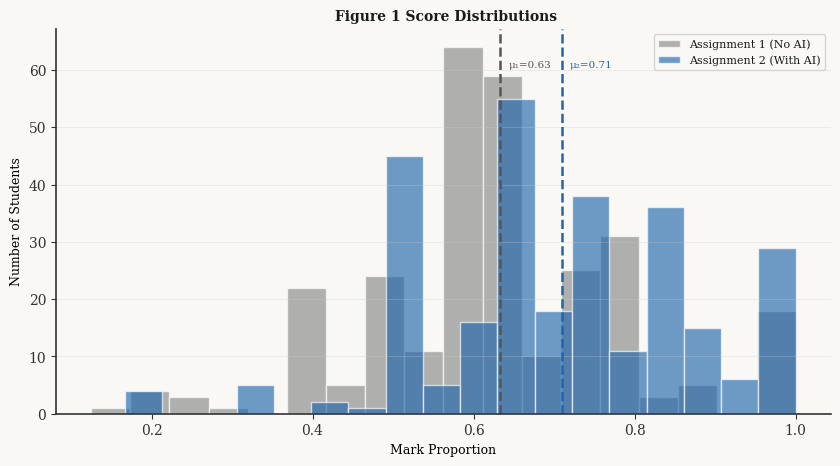

In [6]:
fig, ax = plt.subplots(1, 1,figsize=(10, 5))

ax.hist(scores['assignment1_NOAI'], bins=18, alpha=0.65, color='#888',
        edgecolor='white', label='Assignment 1 (No AI)')
ax.hist(scores['assignment2_AI'],   bins=18, alpha=0.65, color=BLUE,
        edgecolor='white', label='Assignment 2 (With AI)')
for val, col, lbl in [(scores['assignment1_NOAI'].mean(), '#555', 'μ₁'),
                      (scores['assignment2_AI'].mean(),   BLUE,  'μ₂')]:
    ax.axvline(val, color=col, lw=1.8, ls='--')
    ax.text(val + 0.01, ax.get_ylim()[1] * 0.9, f'{lbl}={val:.2f}', fontsize=7.5, color=col)
ax.set_xlabel('Mark Proportion', fontsize=9)
ax.set_ylabel('Number of Students', fontsize=9)
ax.set_title(' Figure 1 Score Distributions', fontsize=10, fontweight='bold')
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.4)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)



# Figure 2 — Behavioral Profiles

Side-by-side horizontal bar charts comparing message-type proportions between improved and declined students. Stars indicate statistically significant differences (t-test).

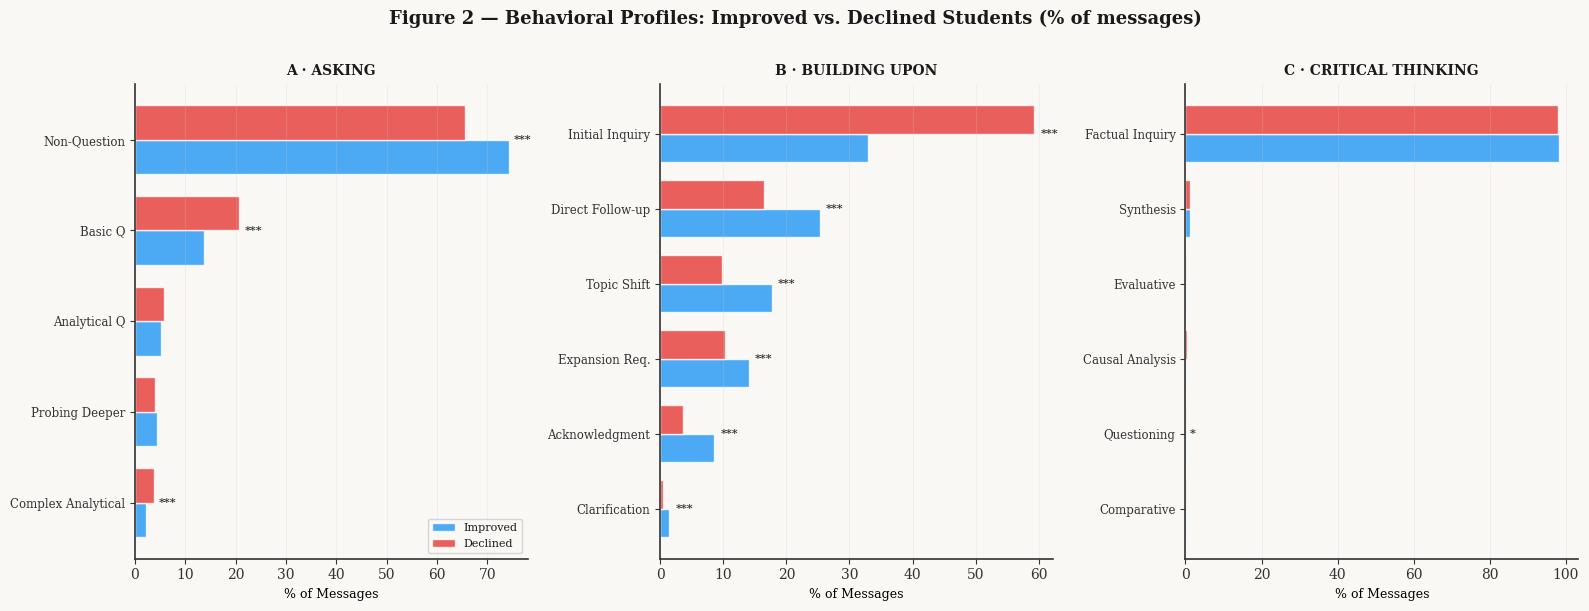

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Figure 2 — Behavioral Profiles: Improved vs. Declined Students (% of messages)',
             fontsize=13, fontweight='bold', y=1.01)

dim_specs = [
    ('A_classifier_soft_label', NODES_A, BLUE,  'A · ASKING'),
    ('B_classifier_soft_label', NODES_B, RED,   'B · BUILDING UPON'),
    ('C_classifier_soft_label', NODES_C, GREEN, 'C · CRITICAL THINKING'),
]

for ax, (col, nodes, color, title) in zip(axes, dim_specs):
    imp_p = imp_df[col].value_counts(normalize=True)
    dec_p = dec_df[col].value_counts(normalize=True)
    imp_v = [imp_p.get(n, 0) * 100 for n in nodes]
    dec_v = [dec_p.get(n, 0) * 100 for n in nodes]
    lbls  = [LABELS.get(n, n) for n in nodes]

    x = np.arange(len(nodes)); w = 0.38
    ax.barh(x + w/2, imp_v, w, color=IMP_COL, alpha=0.8, edgecolor='white', label='Improved')
    ax.barh(x - w/2, dec_v, w, color=DEC_COL, alpha=0.8, edgecolor='white', label='Declined')
    ax.set_yticks(x); ax.set_yticklabels(lbls, fontsize=8.5)
    ax.invert_yaxis()
    ax.set_xlabel('% of Messages', fontsize=9)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    # 2 sample t-test significance stars per node
    for i, n in enumerate(nodes):
        _, p = stats.ttest_ind(imp_df[col].eq(n).astype(int),
                               dec_df[col].eq(n).astype(int))
        star = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
        if star:
            ax.text(max(imp_v[i], dec_v[i]) + 1, i, star,
                    va='center', fontsize=8, color='#333', fontweight='bold')

    if ax == axes[0]:
        ax.legend(fontsize=8, loc='lower right')

plt.tight_layout()
plt.savefig('fig2_profiles.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

In [8]:
from scipy.stats import ttest_ind
from scipy.stats import levene
lev_decisions={}
features=list(merged.columns)

features= ['studId',
 'n_messages',
 'A_non_question',
 'A_basic_question',
 'A_complex_analytical',
 'A_analytical_question',
 'B_topic_shift',
 'B_expansion_request',
 'B_direct_followup',
 'B_initial_inquiry',
 'B_acknowledgment_agreement',
 'B_clarification_request',
 'C_factual_inquiry',
 'C_synthesis_integration',
 'C_causal_analysis',
 'C_questioning_reasoning',
 'C_evaluative_judgment',
 'C_comparative_evaluation',
 'engagement_rate',
 'A_probing_deeper']

In [9]:
from scipy.stats import ttest_ind
from scipy.stats import levene
lev_decisions={}


df_imp_processed = per_student_features(imp_df)
df_dec_processed = per_student_features(dec_df)


# F-test (Levene's Test)
for feat in features:
    g_imp = df_imp_processed[feat]
    g_dec = df_dec_processed[feat]
    
    # Drop NaNs if your data has them, as levene/ttest can return NaN otherwise
    f_lev, p_lev = levene(g_imp.dropna(), g_dec.dropna())
    
    # CORRECTED LOGIC: 
    # If p < 0.05, variances are significantly DIFFERENT -> equal_var = False
    lev_decisions[feat] = p_lev >= 0.05

# T-test
results = []
for feat, equal_var in lev_decisions.items():
    g_imp = df_imp_processed[feat].dropna()
    g_dec = df_dec_processed[feat].dropna()
    
    # Run t-test with the correctly assigned equal_var boolean
    t_stat, p_val = ttest_ind(g_imp, g_dec, equal_var=equal_var)
    
    # Significance labeling
    sig = ('***' if p_val < 0.001 else
           ('**'  if p_val < 0.01  else
            ('*'   if p_val < 0.05  else 'n.s.')))
    
    results.append({'feature': feat, 'p_value': p_val, 'sig': sig})

p_values_df = pd.DataFrame(results)

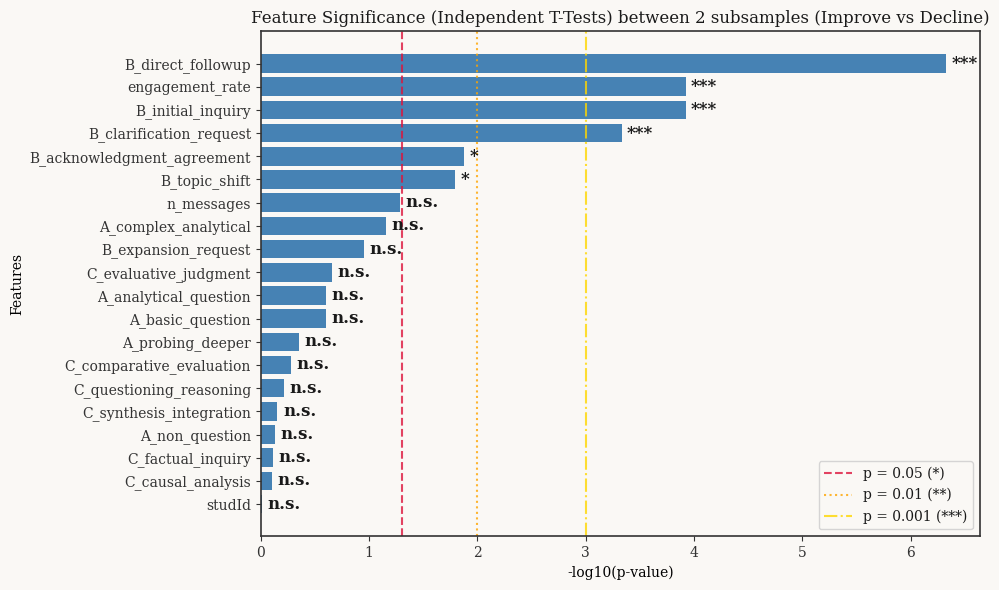

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Save your results into a DataFrame

df_results = p_values_df

#
df_results = pd.DataFrame(results)

# 2. Calculate the -log10 of the p-value for visualization
df_results['-log10(p_value)'] = -np.log10(df_results['p_value'])

# 3. Sort values so the most significant features appear at the top
df_results = df_results.sort_values(by='-log10(p_value)', ascending=True)

# 4. Set up the figure and plot the horizontal bars
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(df_results['feature'], df_results['-log10(p_value)'], color='steelblue')

# 5. Add vertical dashed threshold lines for common significance levels
ax.axvline(-np.log10(0.05), color='crimson', linestyle='--', alpha=0.8, label='p = 0.05 (*)')
ax.axvline(-np.log10(0.01), color='orange', linestyle=':', alpha=0.8, label='p = 0.01 (**)')
ax.axvline(-np.log10(0.001), color='gold', linestyle='-.', alpha=0.8, label='p = 0.001 (***)')

# 6. Annotate the end of each bar with your calculated significance stars
for bar, sig in zip(bars, df_results['sig']):
    ax.text(bar.get_width() + 0.05,
            bar.get_y() + bar.get_height() / 2,
            sig,
            va='center', ha='left', fontsize=12, fontweight='bold')

# 7. Final Formatting touches
ax.set_xlabel('-log10(p-value)')
ax.set_ylabel('Features')
ax.set_title('Feature Significance (Independent T-Tests) between 2 subsamples (Improve vs Decline)')
ax.legend(loc='lower right')

# Expand layout to prevent label cropping and show plot
plt.tight_layout()
plt.show()

In [11]:
import sklearn
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler


#from feature selection
cluster_features = [
    'B_direct_followup', 
    'engagement_rate',  
    'B_topic_shift', 
    'B_clarification_request',
    'B_initial_inquiry',
    'B_acknowledgment_agreement'
]


scaler = StandardScaler()
scaled_features = scaler.fit_transform(merged[cluster_features])

# Find optimal K (Clustering) using Silhouette Score
silhouette_scores = []
K_range = range(2, 10)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(scaled_features)
    silhouette_scores.append(silhouette_score(scaled_features, labels))
    
best_k = K_range[np.argmax(silhouette_scores)]
print(f"Optimal number of clusters (Behavioral Profiles) based on Silhouette Score: {best_k}")




Optimal number of clusters (Behavioral Profiles) based on Silhouette Score: 3


In [12]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
merged['profile_cluster'] = kmeans.fit_predict(scaled_features)

In [13]:
profile_means = merged.groupby('profile_cluster')[cluster_features + ['score_diff', 'assignment1_NOAI', 'assignment2_AI','n_messages']].mean()
profile_means

,B_direct_followup,engagement_rate,B_topic_shift,B_clarification_request,B_initial_inquiry,B_acknowledgment_agreement,score_diff,assignment1_NOAI,assignment2_AI,n_messages
profile_cluster,,,,,,,,,,
0,0.000000,0.006944,0.000463,0.000000,0.993056,0.000000,0.041778,0.637527,0.679306,17.594444
1,0.327257,0.925419,0.287675,0.006722,0.074581,0.081011,0.127046,0.627866,0.754912,49.526316
2,0.292825,0.943711,0.225728,0.101491,0.056289,0.070883,0.230023,0.603311,0.833333,61.600000


In [14]:
profile_means.loc[2, 'n_messages']

np.float64(61.6)

In [15]:
profile_names = {}
for cluster_id in range(best_k):
    mean_eng = profile_means.loc[cluster_id, 'engagement_rate']
    mean_msg = profile_means.loc[cluster_id, 'n_messages']
    
    if mean_eng > 0.75 and mean_msg > 50:
        profile_names[cluster_id] = "Deep Engagers"
    elif mean_eng < 0.45:
        profile_names[cluster_id] = "Surface Searchers"
    else:
        profile_names[cluster_id] = "Moderate Explorers"

profile_names

{0: 'Surface Searchers', 1: 'Moderate Explorers', 2: 'Deep Engagers'}

In [16]:
merged['profile_name'] = merged['profile_cluster'].map(profile_names)
print("\nProfile mapping:")
for k, v in profile_names.items():
    print(f"  Cluster {k} -> {v} (n = {(merged['profile_cluster'] == k).sum()})")


Profile mapping:
  Cluster 0 -> Surface Searchers (n = 180)
  Cluster 1 -> Moderate Explorers (n = 95)
  Cluster 2 -> Deep Engagers (n = 10)


In [17]:
merged.columns

Index(['studId', 'assignment1_NOAI', 'assignment2_AI', 'score_diff',
       'improved', 'n_messages', 'A_non_question', 'A_basic_question',
       'A_complex_analytical', 'A_analytical_question', 'B_topic_shift',
       'B_expansion_request', 'B_direct_followup', 'B_initial_inquiry',
       'B_acknowledgment_agreement', 'B_clarification_request',
       'C_factual_inquiry', 'C_synthesis_integration', 'C_causal_analysis',
       'C_questioning_reasoning', 'C_evaluative_judgment',
       'C_comparative_evaluation', 'engagement_rate', 'A_probing_deeper',
       'profile_cluster', 'profile_name'],
      dtype='str')

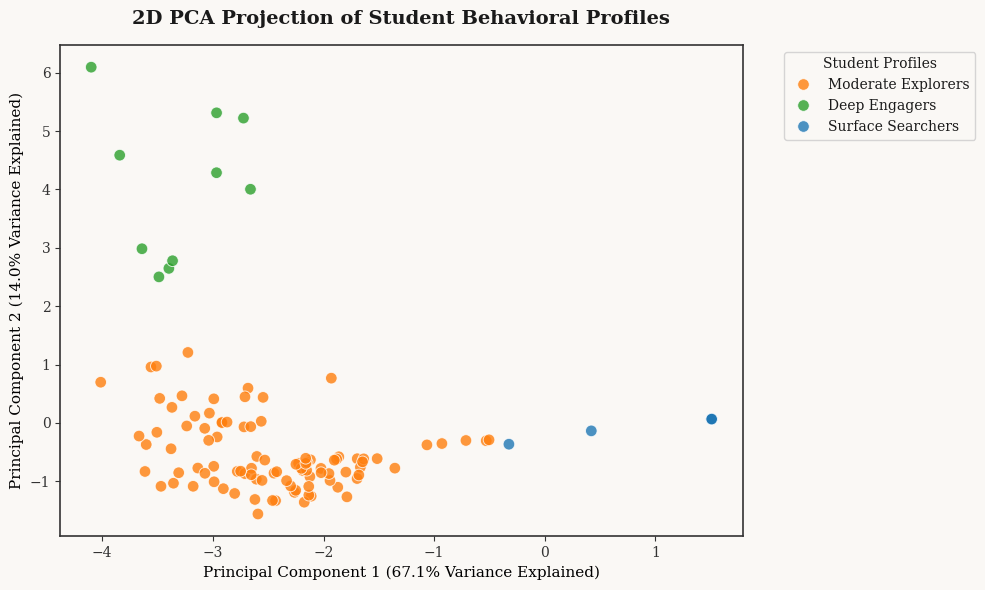

In [18]:
from sklearn.decomposition import PCA
import seaborn as sns

scaler = StandardScaler()
X_scaled = scaler.fit_transform(merged[cluster_features].dropna())


pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


df_pca = merged.dropna(subset=cluster_features).copy()
df_pca['PCA1'] = X_pca[:, 0]
df_pca['PCA2'] = X_pca[:, 1]

profile_palette = {
    'Surface Searchers': '#1f77b4',   # Passive Blue
    'Moderate Explorers': '#ff7f0e',  # Exploratory Orange
    'Deep Engagers': '#2ca02c'        # Deep Green
}

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    data=df_pca, x='PCA1', y='PCA2', hue='profile_name', 
    palette=profile_palette, alpha=0.8, s=70, edgecolor='w', ax=ax
)

ax.set_title('2D PCA Projection of Student Behavioral Profiles', fontsize=14, pad=15, fontweight='bold')
ax.set_xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance Explained)', fontsize=11)
ax.set_ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance Explained)', fontsize=11)
ax.legend(title='Student Profiles', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)

plt.tight_layout()


In [19]:
merged.groupby('profile_name').agg({
    'studId': 'count',                # Sample size (n) per profile
    'n_messages': 'mean',             # Average messages sent PER student
    'engagement_rate': 'mean',        # Average conversational depth
    'score_diff': 'mean',             # Average learning gains (A2 - A1)
    'assignment1_NOAI': 'mean'        # Baseline capability (Pre-test)
}).rename(columns={'studId': 'n_students',
'assignment1_NOAI':'baseline capability (Pre-test)',
'score_diff': 'average learning gains'})


,n_students,n_messages,engagement_rate,average learning gains,baseline capability (Pre-test)
profile_name,,,,,
Deep Engagers,10,61.600000,0.943711,0.230023,0.603311
Moderate Explorers,95,49.526316,0.925419,0.127046,0.627866
Surface Searchers,180,17.594444,0.006944,0.041778,0.637527





To evaluate the relationship between interaction behavioral patterns and academic outcomes, a K-means clustering algorithm was deployed, segmenting the cohort into three distinct behavioral profiles: Deep Engagers, Moderate Searchers, and Surface Searchers. Rather than utilizing the full set of features, the feature space was limited to 
    'B_direct_followup', 
    'engagement_rate',  
    'B_topic_shift', 
    'B_clarification_request',
    'B_initial_inquiry',
    'B_acknowledgment_agreement'.  This targeted feature selection was essential because K-means is a distance base algorithm and having too many features can lead to the problem of ""curse of dimensionality". In addition, To mathematically justify this subset, an independent two-sample t-test pipeline was also executed across the variables, successfully filtering out features that demonstrated statistically significant variance the two primary performance cohorts (the score-improved group versus the score-declined group)


To determine if these behavioral differences translated to distinct academic outcomes, a non-parametric Kruskal-Wallis test was conducted across the profiles using score improvement as the dependent variable. With a p value< 0.0005, we safely reject the null hypothesis, demonstrating that a student's chosen conversational approach with the AI tutor fundamentally dictates their subsequent academic growth.












The clustering Results:

1. The prevalence of superficial AI use (n_messages)

The vast majority of students in the dataset falls into the "Surface Searchers" profile. Insight: This reveals a critical baseline in educational AI research. That when given acccess to a AI chatbot, the default behaviour for most students is highly superficial with a near zero engagement rate (0.006944). There is a clear instructional hurdle. Students need to be taught or require explictit prompting strategies to have better use of AI. In addition the baseline capabilities (determined by initial test score without AI usage) are relatively distributed across groups but their learning gains diverge dramatically. It can be argued that chatbot interaction style or prompting rather than prior knowledge is a primary differentiator of learning gains

2. Conversational depth predicts learning gains (engagement_rate vs. average learning gains)

Learning gains here is measured by the difference in score before and after using AI.

The average learning gains of Deep Engagers (0.95 engagement rate) and Moderate Explorers(0.93 engagement rate) achieve an average learning gains ranging from +0.127 to +0.230, compared to +0.042 for Surface Searchers(0.006944 engagement rate). Insight: Conversaional Depth measured by engagement rate (where students actively follow up on the chatbot's replies) is highly coupled with learning outcomes.

This reinforces the theory of active learning in AI tutoring : cognitive synthesis, clarification, and dialogue refinement are the mechanisms driving conceptual understanding, whereas simple information retrieval (Surface Searching) yields minimal learning gains.




In [20]:
# 1. Kruskal-Wallis Test
groups = [merged.loc[merged['profile_cluster'] == i, 'score_diff'] for i in range(best_k)]
h_val, kw_p_val = stats.kruskal(*groups)
print(f"Kruskal-Wallis Test:")
print(f"H-statistic = {h_val:.4f}, p-value = {kw_p_val:.6f}")
print("-" * 65)
# 2. Pairwise Post-hoc Welch's T-Tests with Dynamic Bonferroni Correction
# CRITICAL FOR PEER REVIEW: For k = 5 clusters, there are k * (k - 1) / 2 = 10 pairwise comparisons.
# Hardcoding n_comparisons = 3 would under-correct for multi-testing. 
# We calculate this dynamically to ensure statistical validity.
n_comparisons = (best_k * (best_k - 1)) // 2
alpha_global = 0.05
bonferroni_threshold = alpha_global / n_comparisons
print(f"Number of Pairwise Comparisons: {n_comparisons}")
print(f"Global Alpha: {alpha_global} | Adjusted Bonferroni Threshold: {bonferroni_threshold:.4f}\n")
posthoc_list = []
for i in range(best_k):
    for j in range(i+1, best_k):
        t_stat, p_raw = stats.ttest_ind(groups[i], groups[j], equal_var=False)
        
        # Calculate Bonferroni-adjusted p-value (standard for journal reporting, capped at 1.0)
        p_adj = min(p_raw * n_comparisons, 1.0)
        is_significant = p_raw < bonferroni_threshold
        
        name_i = profile_names.get(i, f"Cluster {i}")
        name_j = profile_names.get(j, f"Cluster {j}")
        
        posthoc_list.append({
            'Profile A': name_i,
            'Profile B': name_j,
            't-statistic': t_stat,
            'Bonferroni Adj p-value': p_adj,
            'Significant (α=0.05)': "Yes" if is_significant else "No"
        })
# Convert to DataFrame
posthoc_df = pd.DataFrame(posthoc_list)


Kruskal-Wallis Test:
H-statistic = 18.3482, p-value = 0.000104
-----------------------------------------------------------------
Number of Pairwise Comparisons: 3
Global Alpha: 0.05 | Adjusted Bonferroni Threshold: 0.0167



In [21]:
posthoc_df

,Profile A,Profile B,t-statistic,Bonferroni Adj p-value,Significant (α=0.05)
0,Surface Searchers,Moderate Explorers,-3.603379,0.001134,Yes
1,Surface Searchers,Deep Engagers,-4.180871,0.003632,Yes
2,Moderate Explorers,Deep Engagers,-2.303170,0.120174,No


A post-hoc analysis was also performed using independent Welch's t-tests to pinpoint exactly which student behavioral profiles diverged in academic performance. A Bonferroni correction was applied across the three distinct group comparisons.

When evaluating Surface Searchers against Moderate Explorers with Bonferroni-adjusted p-value of 0.0.001134 <0.05., this shows students who engaged in active exploration and frequent topic exploration achieved vastly superior test score improvements compared to their passive peers. This insight is reinforced when contrasting Surface Searchers directly against Deep Engagers with Bonferroni-adjusted p-value of 0.003632 <0.05. This is a clear confirmation that moving away from a surface-level-interaction model yields an immediate boost in student learning gains

Conversely, the analysis between Moderate Explorers and Deep Engagers is more nuanced. While Deep Engagers achieved higher nominal score gains on paper, the Bonferroni-adjusted p-value of 0.120 > 0.05 indicates that this difference is not statistically significant. This suggests that while their conversational styles differ, both active engagement strategies yield comparable academic performance benefits.

Ultimately, the key takeaway is that the key for academic growth when engaging with AI is shifting student's mindset of passive 'searching' into a form of active and iterative conversational dialogue.



### Network Analysis

In [22]:
def draw_network_improved(ax, trans, nodes, color, title, min_w=10):
    """Draw a directed transition network optimized for a smaller figsize (e.g., 10x6)."""
    G = nx.DiGraph()
    G.add_nodes_from(nodes)
    
    # Filter and add edges #IGNORE SELF LOOP
    for (f, t), w in trans.items():
        if f in nodes and t in nodes and f != t and w >= min_w:
            G.add_edge(f, t, weight=w)

    pos = nx.circular_layout(G)
    
    # 1. Scale down nodes: Smaller base size (300) and multiplier (0.1) for tight spaces
    node_sizes = [
        900 + sum(w for (f, t), w in trans.items() 
                  if (f == n or t == n) and f in nodes and t in nodes) * 0.1
        for n in nodes
    ]
    
    ew = [G[u][v]['weight'] for u, v in G.edges()]
    # Cap max thickness so heavy flows don't blot out the small graph (max width 5)
    widths = [1 + (w / max(ew)) * 4 for w in ew] if ew else []

    # 2. Refine edges: Smaller arrowheads (size 10)
    nx.draw_networkx_edges(G, pos, ax=ax, width=widths,
                           edge_color=color, alpha=0.6, arrows=True,
                           arrowstyle='-|>', arrowsize=10, 
                           connectionstyle='arc3,rad=0.2', 
                           node_size=node_sizes)
    
    # Draw nodes: Slightly thinner borders (linewidths 1.0)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=color,
                           node_size=node_sizes, alpha=0.9,
                           linewidths=1.0, edgecolors='white')
    
    # 3. Text formatting: Smaller font (size 7) so it fits inside the smaller circles
    nx.draw_networkx_labels(G, pos,
        labels={n: '\n'.join(LABELS.get(n, str(n)).split()) for n in G.nodes()},
        ax=ax, font_size=7, font_color='black', font_weight='bold')
    
    # Title: Scaled down text and padding
    ax.set_title(title, fontsize=9, fontweight='bold', pad=8)
    ax.axis('off')
    ax.set_facecolor(PANEL)
    
    # 4. CRITICAL: Slightly larger margin (0.25) to prevent edge clipping in tight layouts
    ax.margins(0.25) 
    
    # Legend: Scaled down fonts
    if ew:
        mw = max(ew)
        for scale in [0.3, 0.65, 1.0]:
            ax.plot([], [], lw=1 + scale * 4, color=color, alpha=0.6,
                    label=f'{int(scale * mw):,}')
        ax.legend(fontsize=7, loc='lower left', framealpha=0.8, 
                  title='Transitions', title_fontsize=7)

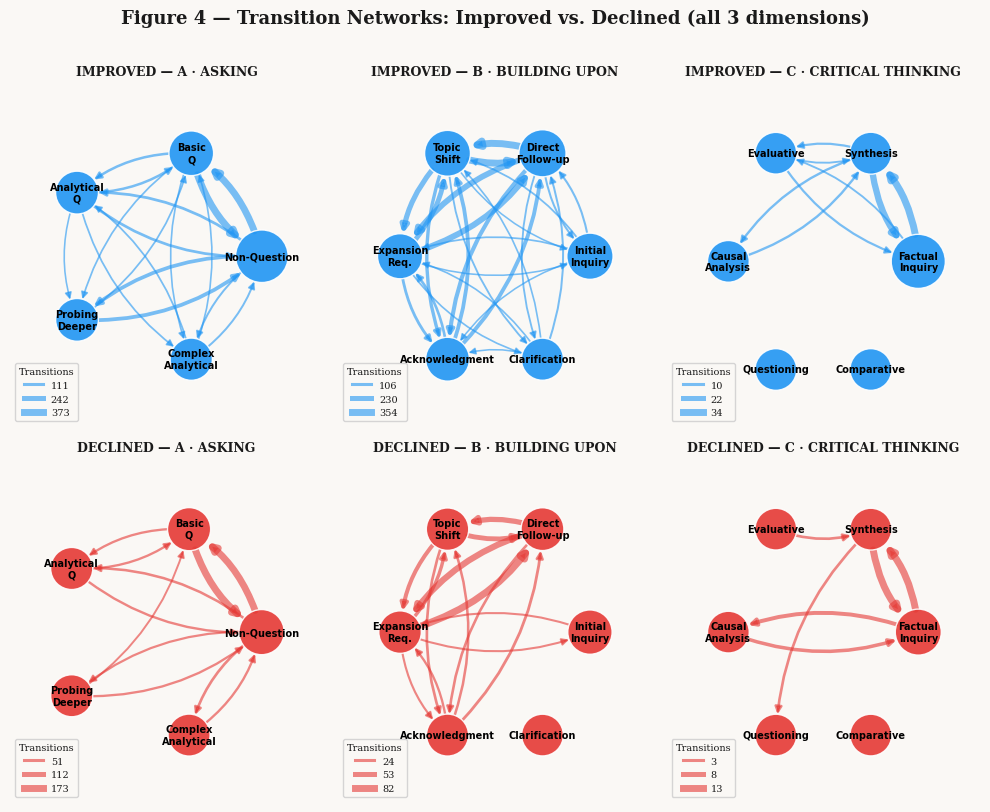

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(10, 8))
fig.suptitle('Figure 4 — Transition Networks: Improved vs. Declined (all 3 dimensions)',
             fontsize=13, fontweight='bold', y=1.01)

for ci, (col, nodes, dim_title, mw) in enumerate(DIM_NET):
    tI = get_transitions(imp_df, col)
    tD = get_transitions(dec_df, col)
    draw_network_improved(axes[0][ci], tI, nodes, IMP_COL, f'IMPROVED — {dim_title}', min_w=mw)
    draw_network_improved(axes[1][ci], tD, nodes, DEC_COL, f'DECLINED — {dim_title}', min_w=mw)

plt.tight_layout()

plt.show()

LEGEND:
Arrows represent flow: In these graphs, every arrow indicates a transition from one state to another
Thickeness Represent volume: The thicker the arrow, the higher the frequency the transition occur


The improved groups demonstrated significantly higher transition volumes and highly interconnected conversational momentum across all dimensions, whereas the declined groups exhibited fragmented,interactions.

A interesting insight is the declining group falling into the "Non-Question" trap in dimension A

- In the improved networks, the thick interconnected webs show that these groups are actively listening and moving the conversation forward together.In contrast, the declined networks show conversations stalling out. The massive traffic ending into 'Non-Question' in dimension A show groups getting stuck. The decline group are talking but not pushing the inquiry forward.

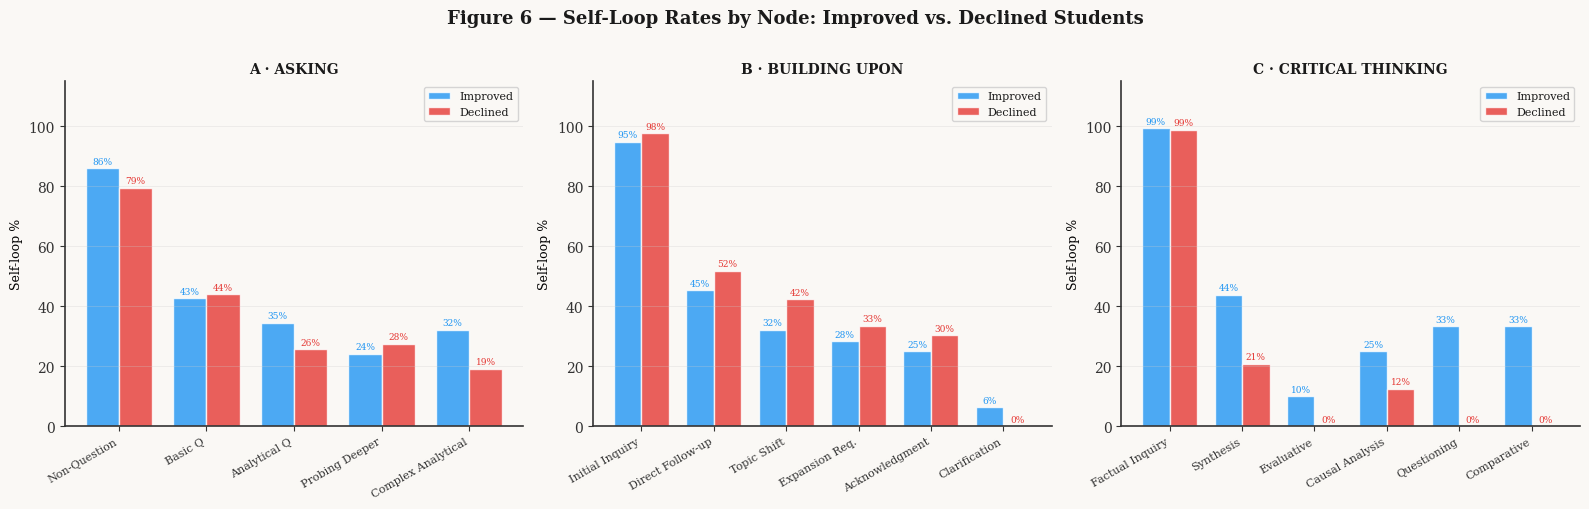


Self-loop rate summary (%):
Node                             Improved   Declined       Diff
--------------------------------------------------------------

A · ASKING
  Non-Question                      86.1%      79.4%      +6.6%
  Basic Q                           42.7%      44.0%      -1.3%
  Analytical Q                      34.5%      25.7%      +8.8%
  Probing Deeper                    24.3%      27.5%      -3.2%
  Complex Analytical                32.1%      19.1%     +13.0%

B · BUILDING UPON
  Initial Inquiry                   94.8%      97.7%      -2.9%
  Direct Follow-up                  45.4%      51.8%      -6.4%
  Topic Shift                       32.1%      42.4%     -10.3%
  Expansion Req.                    28.4%      33.5%      -5.1%
  Acknowledgment                    25.0%      30.3%      -5.2%
  Clarification                      6.3%       0.0%      +6.3%

C · CRITICAL THINKING
  Factual Inquiry                   99.3%      98.9%      +0.5%
  Synthesis           

In [24]:
def self_rates(trans, nodes):
    """Percentage of outgoing transitions that loop back to the same node."""
    rates = []
    for n in nodes:
        self_w = trans.get((n, n), 0)
        total  = sum(trans.get((n, t), 0) for t in nodes)
        rates.append(self_w / total * 100 if total else 0)
    return rates

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Figure 6 — Self-Loop Rates by Node: Improved vs. Declined Students',
             fontsize=13, fontweight='bold', y=1.01)

for ax, (col, nodes, dim_title, _) in zip(axes, DIM_NET):
    tI   = get_transitions(imp_df, col)
    tD   = get_transitions(dec_df, col)
    rI   = self_rates(tI, nodes)
    rD   = self_rates(tD, nodes)
    lbls = [LABELS.get(n, n) for n in nodes]
    x    = np.arange(len(nodes)); w = 0.38

    ax.bar(x - w/2, rI, w, color=IMP_COL, alpha=0.8, edgecolor='white', label='Improved')
    ax.bar(x + w/2, rD, w, color=DEC_COL, alpha=0.8, edgecolor='white', label='Declined')
    ax.set_xticks(x); ax.set_xticklabels(lbls, rotation=30, ha='right', fontsize=8)
    ax.set_ylabel('Self-loop %', fontsize=9)
    ax.set_title(dim_title, fontsize=10, fontweight='bold')
    ax.set_ylim(0, 115); ax.grid(axis='y', alpha=0.4)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.legend(fontsize=8)

    for xi, (vi, vd) in enumerate(zip(rI, rD)):
        ax.text(xi - w/2, vi + 1.5, f'{vi:.0f}%', ha='center', fontsize=6.5, color=IMP_COL)
        ax.text(xi + w/2, vd + 1.5, f'{vd:.0f}%', ha='center', fontsize=6.5, color=DEC_COL)

plt.tight_layout()
plt.savefig('fig6_selfloops.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

# Summary table
print("\nSelf-loop rate summary (%):")
print(f"{'Node':<30} {'Improved':>10} {'Declined':>10} {'Diff':>10}")
print("-" * 62)
for col, nodes, dim_title, _ in DIM_NET:
    tI = get_transitions(imp_df, col)
    tD = get_transitions(dec_df, col)
    print(f"\n{dim_title}")
    for n, ri, rd in zip(nodes, self_rates(tI, nodes), self_rates(tD, nodes)):
        print(f"  {LABELS.get(n,n):<28} {ri:>9.1f}% {rd:>9.1f}% {ri-rd:>+9.1f}%")

The figure illustrates the self-loop rates for both Improved and Declined student groups across all three conversational dimensions. In this context, self-loop is defined as the percentage of times a student engaged in a specific behavior and then immediately followed it up with that exact same behavior.

The data reveals that while both groups frequently self-loop in their respective states, their ability for higher order thinking diverge significantly. In Dimension B (Building Upon), the Declined group exhibited higher self-loop rates across conversational management nodes, notably Topic Shift (42% vs. 32%) and Direct Follow-up (52% vs. 45%). This suggests that rather than elevating the inquiry, the decline groups often gets trapped in repetitive loops.

Conversely, the Improved group demonstrated a capacity for sustained higher-order thinking. In Dimension A (Asking), Improved students were nearly twice as likely to sustain Complex Analytical questioning (32% vs. 19%). This can be seen most in Dimension C (Critical Thinking) where the decline group is reported to show an almost complete inability to self-loop in advance cognitive states while the improved group tend to do a lot better.

So what?



The results from Figure 6 suggests a vital  paradigm shift for AI-driven education: critical thinking is a sustanted state, not an event.  A key finding is the Improved group's ability to self-loop in high-level cognitive states. This indicates that merely prompting an LLM to reach a moment of critical thought is insufficient and that true intellectual rigor requires the coversation momentum to remain in that cognitive state. The declined group poor performance can be attributed to a lack of foundational basis particually on "Asking" and "Building Upon" phases, which are necessary to support and sustain higher order thought.

Moreover, there is a need for conversational scaffolding when integrating LLMs into educational environments. Educators cannot simply instruct groups to think in a higher order such as 'thinking critically' or 'discuss deeply' with AI as previously explained. From Figure 4, the Declined groups are frequently talking to the LLM,but cannot seem to escape conversational stalemates. Future interventions with AI in education must focus on teaching the "micro-skills" of human-AI dialogue. Students require explicit frameworks on how to effectively structure sequential questions, how to iteratively build upon an AI's output, and how to avoid abandoning a line of inquiry prematurely.

In [25]:
ml_features=['n_messages', 'A_non_question', 'A_basic_question',
       'A_complex_analytical', 'A_analytical_question', 'B_topic_shift',
       'B_expansion_request', 'B_direct_followup', 'B_initial_inquiry',
       'B_acknowledgment_agreement', 'B_clarification_request',
       'C_factual_inquiry', 'C_synthesis_integration', 'C_causal_analysis',
       'C_questioning_reasoning', 'C_evaluative_judgment',
       'C_comparative_evaluation', 'engagement_rate', 'A_probing_deeper']

In [26]:
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

In [27]:
X=merged[ml_features]
y=merged['improved']

In [28]:
y.value_counts()

improved
True     195
False     90
Name: count, dtype: int64

"The dataset exhibited a moderate class imbalance (195 Improved vs. 90 Declined). To prevent majority-class bias and the accuracy paradox, the predictive models were initialized with balanced class weights, mathematically adjusting the loss function to penalize misclassifications of the minority class proportionally.

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)


y_pred = rf_model.predict(X_test)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_model, X_train, y_train, cv=cv, scoring="roc_auc")
print("--- 5-Fold Cross-Validation (ROC-AUC) ---")
print(f"Scores per fold: {list(np.round(cv_scores, 3))}")
print(f"Mean CV ROC-AUC: {np.mean(cv_scores):.3f}")

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]
print("--- Final Test Set Performance (Unseen) ---")
print(classification_report(y_test, y_pred))
print(f"Test ROC-AUC Score: {roc_auc_score(y_test, y_proba):.3f}")

--- 5-Fold Cross-Validation (ROC-AUC) ---
Scores per fold: [np.float64(0.852), np.float64(0.721), np.float64(0.66), np.float64(0.483), np.float64(0.636)]
Mean CV ROC-AUC: 0.670
--- Final Test Set Performance (Unseen) ---
              precision    recall  f1-score   support

       False       0.22      0.40      0.29        10
        True       0.85      0.70      0.77        47

    accuracy                           0.65        57
   macro avg       0.53      0.55      0.53        57
weighted avg       0.74      0.65      0.68        57

Test ROC-AUC Score: 0.700


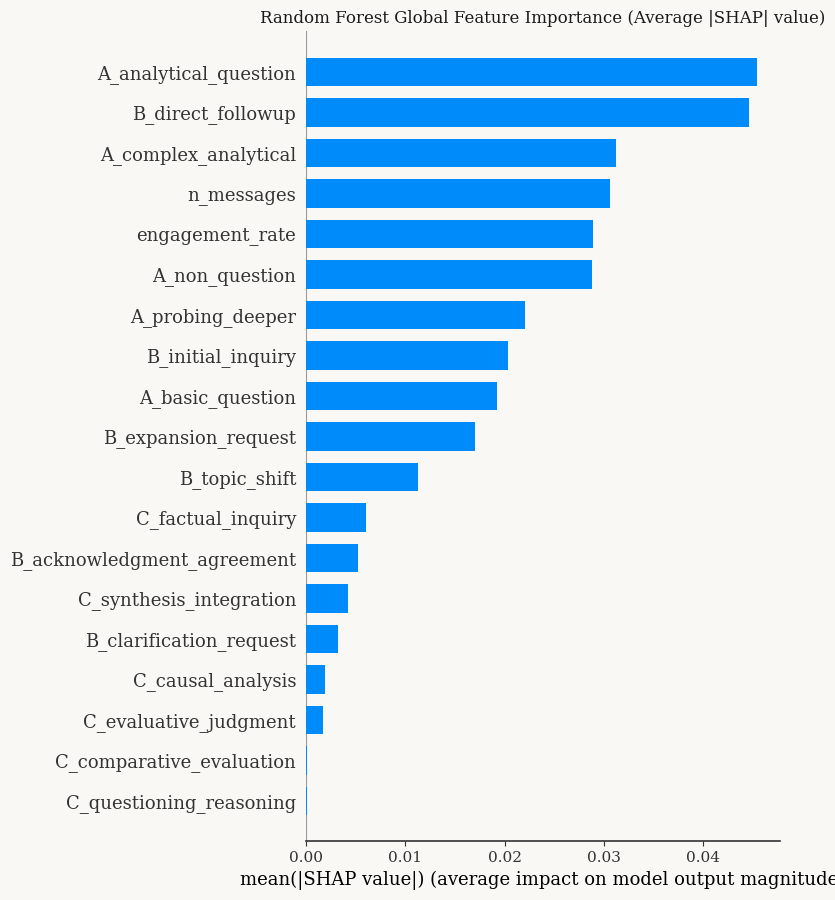

'plt.figure(figsize=(10, 6))\nplt.title("SHAP Beeswarm Plot: Feature Impact on Predictions")\nshap.summary_plot(shap_values_positive, X_test_df, show=False)\nplt.tight_layout()\nplt.show()'

In [ ]:
import numpy as np
import pandas as pd
import shap

X_test_df = pd.DataFrame(X_test, columns=X.columns)


explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_df)

if isinstance(shap_values, list):
    # Old SHAP format: list of length 2 -> [class_0, class_1]
    shap_values_positive = shap_values[1]
elif isinstance(shap_values, np.ndarray) and len(shap_values.shape) == 3:
    # New SHAP format: 3D array of shape (samples, features, classes)
    # Slices the positive class (class 1) from the last dimension
    shap_values_positive = shap_values[:, :, 1]
else:
    shap_values_positive = shap_values

plt.figure(figsize=(10, 6))
plt.title("Random Forest Global Feature Importance (Average |SHAP| value)")
shap.summary_plot(
    shap_values_positive, X_test_df, plot_type="bar", show=False
)
plt.tight_layout()
plt.show()




A random forest model was used to compare feature importance using SHAP (SHapley Additive exPlanations) value. From the figure, features from dimension A and B are heavily relied on when making predictions. In contrast, almost every dimension C features have a near zero impact on the model's predictions. The results suggest success is dictated by the student's ability to act as an effective 'director' of AI. Students who master foundational inquiry (A_analytical_question) and maintain conversational momentum (B_direct_followup) unlock the AI's potential. The AI handles the heavy cognitive lifting, provided the student knows how to ask the right questions. This tells educators exactly where to spend their time. Reinforncing the insights from (), if a teacher wants a student to improve, directly telliing them to engage in dimension C is skiping steps. Instead, educators must focus on scaffolding conversational skills to explicitly strengthen Dimensions A and B, which ultimately drives improved academic performance.

